In [1]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_repeatscout/find_repeats_results/merged.tsv'

In [3]:
df = pl.read_csv(infpath, separator='\t')

In [4]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [5]:
df.head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",241716,251716,"""10000_0_0.0"""
10000,0,0.0,"""true""",516539,526539,"""10000_0_0.0"""
10000,0,0.01,"""true""",241716,251716,"""10000_0_0.01"""
10000,0,0.01,"""true""",268876,278876,"""10000_0_0.01"""
10000,0,0.02,"""true""",241716,251716,"""10000_0_0.02"""


In [6]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [7]:
true_df.shape

(420, 7)

In [8]:
pred_df.shape

(28, 7)

In [9]:
true_df.filter(pl.col('rate') == 0.0).head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",241716,251716,"""10000_0_0.0"""
10000,0,0.0,"""true""",516539,526539,"""10000_0_0.0"""
10000,1,0.0,"""true""",191496,201496,"""10000_1_0.0"""
10000,1,0.0,"""true""",454789,464789,"""10000_1_0.0"""
10000,2,0.0,"""true""",132947,142947,"""10000_2_0.0"""


In [10]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [11]:
MAX_ERROR_BP = 10

In [12]:
repeat_id_list = list()
repeat_start_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():
        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & ( (pl.col('start_coord') - true_row['start_coord']).abs() <= MAX_ERROR_BP ) \
          & ( (pl.col('end_coord')   - true_row['end_coord']).abs() <= MAX_ERROR_BP )
        )

        found_value = 0
        if curr_pred_detect_df.shape[0] > 0:
            found_value = 1
        # end if

        repeat_id_list.append(repeat_id)
        repeat_start_coord_list.append(true_row['start_coord'])
        repeat_found_list.append(found_value)
    # end for
# end for

In [13]:
print(len(repeat_id_list))
print(len(repeat_start_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'repeat_id': repeat_id_list,
    'repeat_start_coord': repeat_start_coord_list,
    'repeat_detected': repeat_found_list,
})

420
420
420


In [14]:
repeat_detect_df.shape

(420, 3)

In [15]:
assert repeat_detect_df.shape[0] == true_df.shape[0]

In [16]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col('repeat_id', 'repeat_start_coord', 'repeat_detected', 'repeat_len', 'repeat_idx', 'rate')
).unique()

In [17]:
repeat_detect_df.shape

(420, 6)

In [18]:
repeat_detect_df.head()

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""1000_8_0.0""",197216,0,1000,8,0.0
"""10000_2_0.01""",415497,0,10000,2,0.01
"""127_1_0.02""",433695,0,127,1,0.02
"""127_3_0.01""",144056,0,127,3,0.01
"""5000_2_0.02""",48965,0,5000,2,0.02


In [19]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.0) & (pl.col('repeat_len') == 1000)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""1000_0_0.0""",289295,0,1000,0,0.0
"""1000_0_0.0""",70818,0,1000,0,0.0
"""1000_1_0.0""",77116,0,1000,1,0.0
"""1000_1_0.0""",263501,0,1000,1,0.0
"""1000_2_0.0""",110477,0,1000,2,0.0
…,…,…,…,…,…
"""1000_7_0.0""",259307,0,1000,7,0.0
"""1000_8_0.0""",197216,0,1000,8,0.0
"""1000_8_0.0""",409939,0,1000,8,0.0


In [20]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.02) & (pl.col('repeat_len') == 10000) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""10000_0_0.02""",375818,0,10000,0,0.02
"""10000_0_0.02""",241716,0,10000,0,0.02
"""10000_1_0.02""",457578,0,10000,1,0.02
"""10000_1_0.02""",191496,0,10000,1,0.02
"""10000_2_0.02""",379053,0,10000,2,0.02
…,…,…,…,…,…
"""10000_7_0.02""",281026,0,10000,7,0.02
"""10000_8_0.02""",179190,0,10000,8,0.02
"""10000_8_0.02""",353987,0,10000,8,0.02


In [21]:
df.filter(
    (pl.col('rate') == 0.02) & (pl.col('repeat_len') == 10000) & (pl.col('repeat_idx') == 84)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str


In [22]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 140


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,0,0.0
0.01,0,0.0
0.02,0,0.0


In [23]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).shape[0]
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

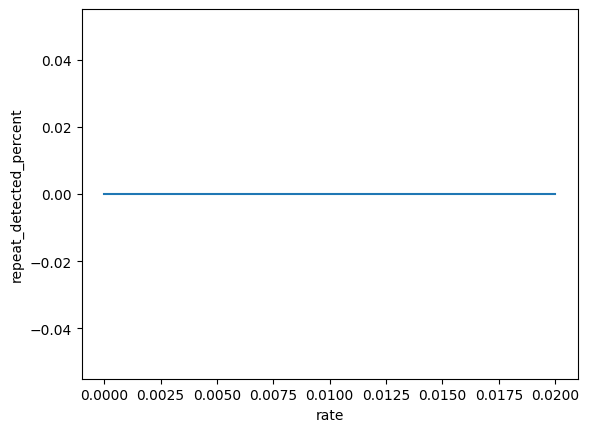

In [24]:
sns.lineplot(
    per_rate_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 20
shape: (3, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 0                     ┆ 0.0                     │
│ 0.01 ┆ 0                     ┆ 0.0                     │
│ 0.02 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

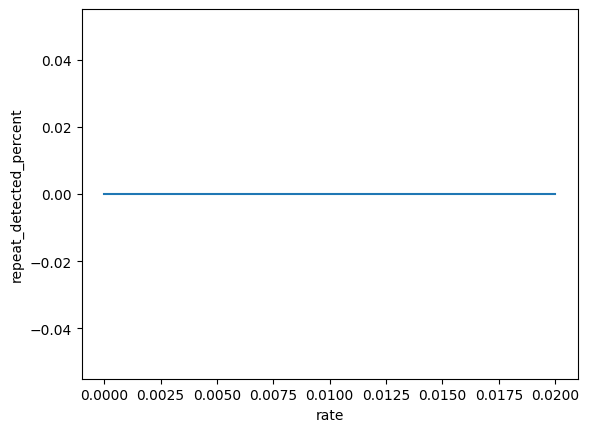

In [25]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
print(per_rate_len127_summary_df.head(10))

sns.lineplot(
    per_rate_len127_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 20
shape: (3, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 0                     ┆ 0.0                     │
│ 0.01 ┆ 0                     ┆ 0.0                     │
│ 0.02 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

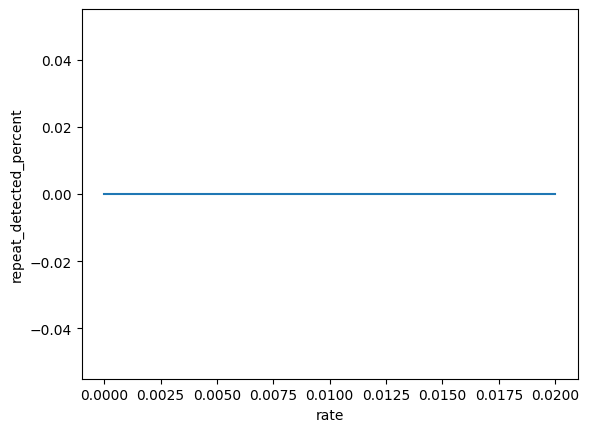

In [26]:
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
print(per_rate_len200_summary_df.head(10))

sns.lineplot(
    per_rate_len200_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 20
shape: (3, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 0                     ┆ 0.0                     │
│ 0.01 ┆ 0                     ┆ 0.0                     │
│ 0.02 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

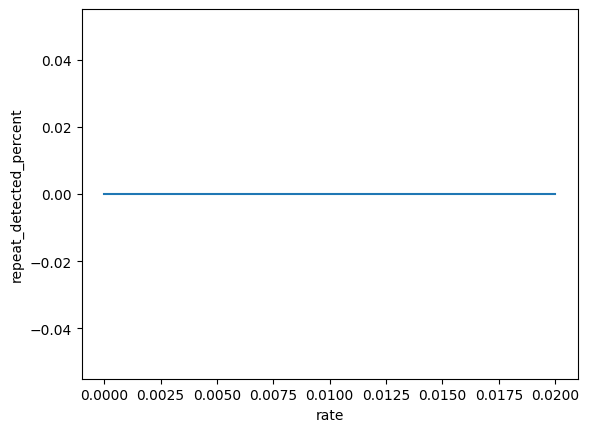

In [27]:
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
print(per_rate_len500_summary_df.head(10))

sns.lineplot(
    per_rate_len500_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 20
shape: (3, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 0                     ┆ 0.0                     │
│ 0.01 ┆ 0                     ┆ 0.0                     │
│ 0.02 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

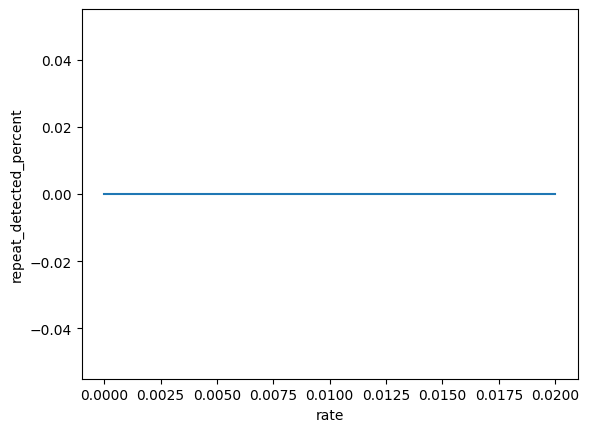

In [28]:
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
print(per_rate_len1k_summary_df.head(10))

sns.lineplot(
    per_rate_len1k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

N_repeats = 20
shape: (3, 3)
┌──────┬───────────────────────┬─────────────────────────┐
│ rate ┆ repeat_detected_count ┆ repeat_detected_percent │
│ ---  ┆ ---                   ┆ ---                     │
│ f64  ┆ i64                   ┆ f64                     │
╞══════╪═══════════════════════╪═════════════════════════╡
│ 0.0  ┆ 0                     ┆ 0.0                     │
│ 0.01 ┆ 0                     ┆ 0.0                     │
│ 0.02 ┆ 0                     ┆ 0.0                     │
└──────┴───────────────────────┴─────────────────────────┘


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

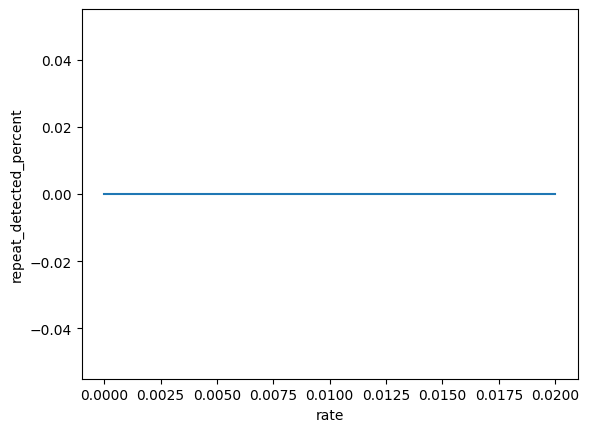

In [29]:
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
print(per_rate_len10k_summary_df.head(10))

sns.lineplot(
    per_rate_len10k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

# Make total plot

In [30]:
per_rate_len127_summary_df = per_rate_len127_summary_df.with_columns(pl.lit(127).alias('repeat_len'))
per_rate_len200_summary_df = per_rate_len200_summary_df.with_columns(pl.lit(200).alias('repeat_len'))
per_rate_len500_summary_df = per_rate_len500_summary_df.with_columns(pl.lit(500).alias('repeat_len'))
per_rate_len1k_summary_df = per_rate_len1k_summary_df.with_columns(pl.lit(1000).alias('repeat_len'))
per_rate_len10k_summary_df = per_rate_len10k_summary_df.with_columns(pl.lit(10000).alias('repeat_len'))

In [31]:
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,0,0.0,"""127"""
0.01,0,0.0,"""127"""
0.02,0,0.0,"""127"""
0.0,0,0.0,"""200"""
0.01,0,0.0,"""200"""


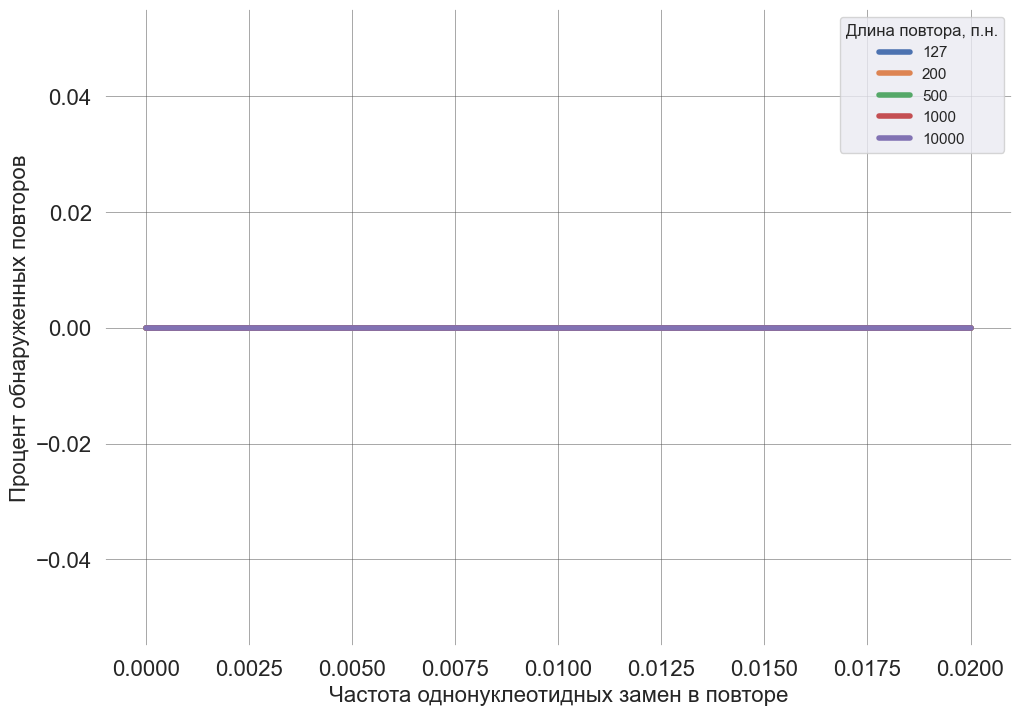

In [32]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)